In [3]:
import os
from datetime import datetime
import math
import matplotlib.pyplot as plt
import numpy as np

# Imports from PyTorch.
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch import nn, Tensor, device, no_grad, manual_seed
from torch import max as torch_max
from torch.utils.data import DataLoader
from torchvision.datasets.utils import download_url
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from copy import deepcopy
#import

import sys
# get the path of the current file
file = os.path.abspath('')
path = os.path.join(file, '../../src')
sys.path.append(path)
print(path)


# Imports from aihwkit.
from aihwkit.nn import AnalogConv2d, AnalogLinear, AnalogSequential
from aihwkit.optim import AnalogSGD
from aihwkit.simulator.configs.configs import (
    InferenceRPUConfig,
    TorchInferenceRPUConfig,
    # remember, the InferenceRPUConfig configuration parameter is used only for inference:
    # this means that the hardware non-idealities are considered only in the forward pass,
    # while the backward and update passes are ideal.
)
from aihwkit.simulator.configs import MappingParameter
from aihwkit.simulator.configs import (
    SingleRPUConfig,
    FloatingPointRPUConfig,
    ConstantStepDevice,
    FloatingPointDevice,
)


from aihwkit.simulator.parameters import (
    WeightClipParameter,
    WeightQuantizerParameter,
)
from aihwkit.simulator.parameters.enums import WeightQuantizerType

from aihwkit.nn.conversion import convert_to_analog, convert_to_digital
from aihwkit.simulator.presets import StandardHWATrainingPreset
from aihwkit.simulator.parameters.enums import WeightClipType
src = os.getcwd()
src = os.path.abspath(os.path.join(src, '../src'))
sys.path.append(src)

import plotting as pl


from aihwkit.simulator.rpu_base import cuda

cur_dir = os.getcwd()
print("Current directory: ", cur_dir)
src_path = os.path.join(cur_dir, "..")
sys.path.append(src_path)
import src.plotting as pl 

# Check device
USE_CUDA = 0
if cuda.is_compiled():
    USE_CUDA = 1

if USE_CUDA:
    torch.cuda.set_device(0)
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")
print("Device: ", DEVICE)




# Path to store datasets
PATH_DATASET = os.path.join(cur_dir, "../data/cifar10")
print("Path to store datasets: ", PATH_DATASET)



# Training parameters
SEED = 1
N_EPOCHS = 100
BATCH_SIZE = 512
LEARNING_RATE = 0.01
N_CLASSES = 10

/home/ecabiati/cellar/aihwkit/sandbox/cuda/../../src
Current directory:  /home/ecabiati/cellar/aihwkit/sandbox/cuda
Device:  cuda:0
Path to store datasets:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/cifar10


## Define the model to be used for evaluation

The model used for evaluation is a 9-layer ResNet (He et al. 2015) for image classification on CIFAR-10 dataset (https://github.com/matthias-wright/cifar10-resnet/). We will load the pre-trained model, fine-tune it, using both hardware aware and quantization aware training, and finally evaluate and compare the performance of the models for different quantization levels.

In [4]:
class LambdaLayer(torch.nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(torch.nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option="A", RPU_CONFIG=None):
        super(BasicBlock, self).__init__()
        self.conv1 = AnalogConv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn1 = torch.nn.BatchNorm2d(planes)
        self.conv2 = AnalogConv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn2 = torch.nn.BatchNorm2d(planes)

        self.shortcut = AnalogSequential()
        if stride != 1 or in_planes != planes:
            if option == "A":
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(
                        x[:, :, ::2, ::2],
                        (0, 0, 0, 0, planes // 4, planes // 4),
                        "constant",
                        0,
                    )
                )
            elif option == "B":
                self.shortcut = AnalogSequential(
                    AnalogConv2d(
                        in_planes,
                        self.expansion * planes,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                        rpu_config=RPU_CONFIG,
                    ),
                    torch.nn.BatchNorm2d(self.expansion * planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


def resnet9s_analog(channels, RPU_CONFIG, FIRST_LAYER_RPU_CONFIG):
    """
    From https://github.com/matthias-wright/cifar10-resnet/
    """

    # resnet9 [56,112,224,224]
    # resnet9s [28,28,28,56]

    if FIRST_LAYER_RPU_CONFIG is None:
        print("First layer RPU config is None")
        FIRST_LAYER_RPU_CONFIG = RPU_CONFIG
    
    model = AnalogSequential(
        # prep
        AnalogConv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=FIRST_LAYER_RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[0], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        # Layer 1
        AnalogConv2d(
            in_channels=channels[0],
            out_channels=channels[1],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[1], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[1], planes=channels[1], stride=1, RPU_CONFIG=RPU_CONFIG),
        # Layer 2
        AnalogConv2d(
            in_channels=channels[1],
            out_channels=channels[2],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[2], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 3
        AnalogConv2d(
            in_channels=channels[2],
            out_channels=channels[3],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[3], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[3], planes=channels[3], stride=1, RPU_CONFIG=RPU_CONFIG),
        torch.nn.MaxPool2d(kernel_size=4, stride=4),
        torch.nn.Flatten(),
        AnalogLinear(in_features=channels[3], out_features=10, bias=True, rpu_config=RPU_CONFIG)
    )

    return model

def create_analog_network(RPU_CONFIG, FIRST_LAYER_RPU_CONFIG = None):
    return resnet9s_analog([28,28,28,56], RPU_CONFIG,  FIRST_LAYER_RPU_CONFIG = None)



In [5]:
class EarlyStopper:
    def __init__(self, patience=10, min_delta=0.005):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss >= (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

class TorchCutout(object):
    def __init__(self, length, fill=(0.0, 0.0, 0.0)):
        self.length = length
        self.fill = torch.tensor(fill).reshape(shape=(3, 1, 1))

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)
        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)
        img[:, y1:y2, x1:x2] = self.fill
        return img

def load_images():
    # train_set = datasets.CIFAR10(root='../data/cifar10', train=True, download=True, transform=transforms.ToTensor())
    # val_set = datasets.CIFAR10(root='../data/cifar10', train=False, download=True, transform=transforms.ToTensor())

    transform_train = transforms.Compose(
        [
            torchvision.transforms.RandomCrop(32, padding=4),
            torchvision.transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), 
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010)
            ),
            TorchCutout(length=8)
            ])
    
    transform_test = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
            ),
        ]
    )

    train_set = datasets.CIFAR10(PATH_DATASET, train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10(PATH_DATASET, train=False, download=True, transform=transform_test)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def create_sgd_optimizer(model, learning_rate):
    """Create the analog-aware optimizer.

    Args:
        model (nn.Module): model to be trained
        learning_rate (float): global parameter to define learning rate
    Returns:
        Optimizer: optimizer
    """
    optimizer = AnalogSGD(model.parameters(), lr=learning_rate, momentum=0.8, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    optimizer.regroup_param_groups(model)

    return optimizer , scheduler


def train_step(train_data, model, criterion, optimizer, scheduler):
    """Train network.

    Args:
        train_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss
        optimizer (Optimizer): analog model optimizer

    Returns:
        nn.Module, Optimizer, float: model, optimizer, and epoch loss
    """
    total_loss = 0

    model.train()

    for images, labels in train_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        # Add training Tensor to the model (input).
        output = model(images)
        loss = criterion(output, labels)

        # Run training (backward propagation).
        loss.backward()

        # Clipping the gradients for quantization.
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimize weights.
        optimizer.step()
        total_loss += loss.item() * images.size(0)

        # clean GPU cache
        # torch.cuda.empty_cache()

    epoch_loss = total_loss / len(train_data.dataset)

    scheduler.step()

    return model, optimizer, epoch_loss


def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


def training_loop(model, criterion, optimizer, scheduler, train_data, validation_data, epochs, RESULTS, model_name, print_every=1):
    """Training loop.

    Args:
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss
        optimizer (Optimizer): analog model optimizer
        train_data (DataLoader): Validation set to perform the evaluation
        validation_data (DataLoader): Validation set to perform the evaluation
        epochs (int): global parameter to define epochs number
        print_every (int): defines how many times to print training progress

    Returns:
        nn.Module, Optimizer, Tuple: model, optimizer, and a tuple of
            lists of train losses, validation losses, and test error

    """

    os.makedirs(RESULTS, exist_ok=True)
    train_losses = []
    valid_losses = []
    test_error = []
    accuracies = []
    early_stopper = EarlyStopper(patience=15, min_delta=0.05)
    best_accuracy = 0

    # Train model
    for epoch in range(0, epochs):
        # Train_step
        model, optimizer, train_loss = train_step(train_data, model, criterion, optimizer, scheduler)
        train_losses.append(train_loss)

        # if epoch % print_every == (print_every - 1):
        #     pl.generate_moving_hist(model, title = "QUANTIZED model", file_name = "./test/test.gif", range = (-1., 1.), top = None, split_by_rows=False)
        #     # first_layer = next(model.analog_tiles())
        #     # plt.scatter(epoch,first_layer.get_forward_parameters()["res"].data.cpu().numpy().flatten())
        #     # plt.ylim(0,2)
        #     # plt.xlim(0,epochs)
        #     # plt.title("First layer weights")
        #     # plt.savefig(os.path.join("./test", "first_layer_alpha.png"))

                    

        # Validate_step
        with no_grad():
            model, valid_loss, error, accuracy = test_evaluation(
                validation_data, model, criterion
            )
            valid_losses.append(valid_loss)
            test_error.append(error)
            accuracies.append(accuracy)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), os.path.join(RESULTS, model_name))

        if epoch % print_every == (print_every - 1):
            print(
                f"{datetime.now().time().replace(microsecond=0)} --- "
                f"Epoch: {epoch}\t"
                f"lr: {optimizer.param_groups[0]["lr"]:.2e}\t"
                f"Train loss: {train_loss:.4f}\t"
                f"Valid loss: {valid_loss:.4f}\t"
                f"Test error: {error:.2f}%\t"
                f"Test accuracy: {accuracy:.2f}%\t"
            )
        
        # Early stopping
        if early_stopper.early_stop(valid_loss):             
            break

        # plot the weights of the model
        # pl.generate_moving_hist(model, title = "DISCRETIZED model", file_name = "../this_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)


    # Save results and plot figures
    np.savetxt(os.path.join(RESULTS, "Test_error.csv"), test_error, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Train_Losses.csv"), train_losses, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Valid_Losses.csv"), valid_losses, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Test_accuracy.csv"), accuracies, delimiter=",")
    plot_results(train_losses, valid_losses, test_error, accuracies, RESULTS)

    return model, optimizer, (train_losses, valid_losses, test_error, accuracies)


def plot_results(train_losses, valid_losses, test_error, accuracies, RESULTS):
    """Plot results.

    Args:
        train_losses (List): training losses as calculated in the training_loop
        valid_losses (List): validation losses as calculated in the training_loop
        test_error (List): test error as calculated in the training_loop
    """
    fig = plt.plot(train_losses, "r-s", valid_losses, "b-o")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:2], ["Training Losses", "Validation Losses"])
    plt.xlabel("Epoch number")
    plt.ylabel("Loss [A.U.]")
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_losses.png"))
    plt.close()

    fig = plt.plot(test_error, "r-s")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:1], ["Test Error"])
    plt.xlabel("Epoch number")
    plt.ylabel("Test Error [%]")
    plt.yscale("log")
    plt.ylim((5e-1, 1e2))
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_error.png"))
    plt.close()

    fig = plt.plot(accuracies, color = "slateblue", marker = "s")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:1], ["Test Accuracy"])
    plt.xlabel("Epoch number")
    plt.ylabel("Test Accuracy [%]")
    plt.ylim((0, 100))
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_accuracy.png"))
    plt.close()


## RPU configuration
We define the RPU configuration that will be used for the training.
Specifically, we mimic the drift noise obtained from the experimental data reported in <a href="https://ieeexplore.ieee.org/abstract/document/10529438">Drift Compensation in Multilevel PCM for in-Memory Computing Accelerators</a>

In [6]:
DRIFT_NOISE_TYPE = -1

MAP_LEVEL_FILE = {
        3 : "matlab/4bit.mat",
        5 : "matlab/4bit.mat",
        9 : "matlab/4bit.mat",
        17 : "matlab/4bit.mat",
        33 : "matlab/4bit.mat"
    }

In [7]:


from aihwkit.simulator.parameters import (
    IOParameters,
    WeightClipParameter,
    WeightRemapParameter,
    WeightModifierParameter,
)

from aihwkit.simulator.parameters.enums import (
    WeightClipType,
    BoundManagementType,
    NoiseManagementType,
    WeightNoiseType,
    WeightRemapType,
    WeightModifierType,
)

from aihwkit.inference.converter.conductance import SinglePairConductanceConverter
from src.utilities import interpolate
from src.noise import ExperimentalNoiseModel, JustStdNoiseModel, JustMedianNoiseModel
from aihwkit.simulator.tiles.torch_tile import TorchSimulatorTile

forward = IOParameters(
    inp_res = 254.0,
    out_res = 254.0,
    # bound_management= BoundManagementType.NONE,
    # noise_management= NoiseManagementType.NONE,
    w_noise_type= WeightNoiseType.NONE,
)

clip = WeightClipParameter(
    type=WeightClipType.NONE,
)

remap = WeightRemapParameter(
    type=WeightRemapType.NONE,
)

quantizer = WeightQuantizerParameter(
    quantizer_type=WeightQuantizerType.NONE,
)

# quantizer = WeightQuantizerParameter(
#     quantizer_type = WeightQuantizerType.UNIFORM_SYMMETRIC,
#     method = "none",
#     levels = 3,
#     rel_to_actual_wmax=True,
#     resolution = .85,
# )

# quantizer = WeightQuantizerParameter(
#     quantizer_type = WeightQuantizerType.UNIFORM_SYMMETRIC,
#     method = "percentile",
#     eps = 0.1,
#     levels = 3,
#     use_forward=True,
# )

quantizer = None



# extract the experimental data
ex_path = f"../data/matlab/4bit.mat"
variables = interpolate(levels=3, file_path=ex_path, force_interpolation=True)
types = variables['str']
print( "The types of noises are: ", types)

drift_compensation = None

def create_rpu_config(level,add_noise = False):
    gmax = 40.0
    modifier = WeightModifierParameter(
        type=WeightModifierType.NONE,
    )
    noise_model = None

    if level != 0:
        noise_model = ExperimentalNoiseModel(file_path=ex_path, 
                                        type = types[DRIFT_NOISE_TYPE],
                                        levels = level,
                                        force_interpolation=True,
                                        compensation=False,
                                        g_converter = SinglePairConductanceConverter(g_max=gmax))
        
        shift_std_devs = [0. for i in range(level)] # std. devs of the noise for each level (in uS)
        shift_values = [-gmax + i * 2*gmax/(level-1) for i in range(level)] #  median values of the noise for each level (in uS)
        
        if add_noise:
            variables = interpolate(levels=level, type = types[DRIFT_NOISE_TYPE], file_path=ex_path, force_interpolation=True)
            print("The medians are: ", variables['ww_mdn'].tolist())
            print("The stds are: ", variables['ww_std'].tolist())
            shift_std_devs=(variables['ww_std']*1e6).tolist()
            shift_values=(variables['ww_mdn']*1e6).tolist()


        # Model the type of noise with the QUANTIZE_ADD_AND_SHIFT modifier type

        modifier = WeightModifierParameter(
            type = WeightModifierType.QUANTIZE_ADD_AND_SHIFT,
            g_max = gmax,
            res =1./(level),
            levels = level,
            shift_std_devs=shift_std_devs,
            shift_values=shift_values,
            rel_to_actual_wmax=True,
            # learnable_step=True,
            per_batch_sample=True,
        )

        # modifier = WeightModifierParameter(
        #     type = WeightModifierType.DISCRETIZE,
        #     res =1./level,
        #     # type = WeightModifierType.ADD_NORMAL,
        #     # std_dev = 0.1,
        #     levels =level,
        #     learnable_step=True, 
        #     # per_batch_sample=True,  
        # )


    rpu_config =TorchInferenceRPUConfig(
        forward = forward,
        clip = clip,
        remap = remap,
        modifier = modifier,
        quantization = quantizer,
        drift_compensation = drift_compensation,
        noise_model = noise_model,
    )

    return rpu_config


The types of noises are:  ['Prog', '1d,RT', '30d,RT', '1d,60°C', '1d,90°C', '1d,120°C', '1d,150°C', '1d,180°C']


In [8]:
from shared import resnet9s

def train_base():
    model = resnet9s().to(DEVICE)
    # Load datasets
    train_data, validation_data = load_images()

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    model, optimizer, _ = training_loop(
        model, criterion, optimizer, scheduler, train_data, validation_data, N_EPOCHS, "resnet9_base_results", "resnet9_base.th"
    )

def train_base_analog():
    
    train_data, validation_data = load_images()

    rpu_config = TorchInferenceRPUConfig()
    rpu_config.quantization = None

    model = create_analog_network(rpu_config, rpu_config).to(DEVICE)
    if USE_CUDA:
        model.cuda()
    optimizer = AnalogSGD(model.parameters(), lr=LEARNING_RATE*0.1, momentum=0.8, weight_decay=0.005)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    optimizer.regroup_param_groups(model)
    criterion = nn.CrossEntropyLoss()

    cuda_check = next(model.parameters()).is_cuda
    print("Model is on cuda: ", cuda_check)

    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 analog base Example")
    model, optimizer, _ = training_loop(
        model, criterion, optimizer, scheduler ,train_data, validation_data, 60, "resnet9_base_results_torch", "resnet9_base_torch.th"
    )
    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 analog base Example")
    
    

def from_scratch(level: int, learning_rate: float = LEARNING_RATE*0.1, add_noise: bool =False):
    RESULTS = os.path.join(cur_dir, "resnet9_qhwa_{}_results_from_scratch".format(level))
    print("Path to store the results: ", RESULTS)
    os.makedirs(RESULTS, exist_ok=True)
    manual_seed(SEED)

    # Load datasets
    train_data, validation_data = load_images()

    # Create RPU configuration
    rpu_config = create_rpu_config(level, add_noise)
    print("RPU config: ", rpu_config)

    # =========== FIRST LAYER RPU CONFIG =========== 
    first_layer_rpuconfig = deepcopy(rpu_config)
    
    # =========== FIRST LAYER RPU CONFIG =========== 

    model = create_analog_network(rpu_config, first_layer_rpuconfig).to(DEVICE)
    if USE_CUDA:
        model.cuda()


    optimizer, scheduler = create_sgd_optimizer(model, learning_rate)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    
    criterion = FocalLoss()

    cuda_check = next(model.parameters()).is_cuda
    print("Model is on cuda: ", cuda_check)

    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 from scratch Example")
    model, optimizer, _ = training_loop(
        model, criterion, optimizer, scheduler ,train_data, validation_data, N_EPOCHS, RESULTS, "resnet9_quant_{}.th".format(level)
    )
    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 from scratch Example")



def finetune(level: int, learning_rate: float = LEARNING_RATE*0.1,  add_noise: bool = False, resnet_path:str = cur_dir + "/../resnet/resnet9s.th" ):
    RESULTS = os.path.join(cur_dir, "resnet9_qhwa_{}_results".format(level))
    print("Path to store the results: ", RESULTS)
    os.makedirs(RESULTS, exist_ok=True)
    manual_seed(SEED)

    # Load datasets
    train_data, validation_data = load_images()

    # Create RPU configuration
    rpu_config = create_rpu_config(level, add_noise)
    print("RPU config: ", rpu_config)

    RESNET_NON_QUANTIZED = resnet_path
    state_dict = torch.load(RESNET_NON_QUANTIZED, map_location=DEVICE)
    
    if "model_state_dict" in state_dict.keys():
        loading_state = state_dict["model_state_dict"]
    else:
        loading_state = state_dict
    

    analog_model = resnet9s().to(DEVICE)
    # print(analog_model)
    if USE_CUDA:
        analog_model.cuda()
    analog_model.load_state_dict(loading_state,strict= False) # load state from analog model
    analog_model = convert_to_analog(analog_model, rpu_config)

    #freeze the first layers N layers:
    N = 4
    for name, param in analog_model.named_parameters():
        if "analog" in name:
            param.requires_grad = False
            N -= 1
        if N == 0:
            break
        
    # print(analog_model)


    # pl.generate_moving_hist(analog_model, title = "DISCRETIZED model", file_name = "./test/this_analog_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)


    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 Example")

    optimizer, _ = create_sgd_optimizer(analog_model, learning_rate)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    # criterion = FocalLoss()
    criterion = nn.CrossEntropyLoss()

    analog_model, optimizer, _ = training_loop(
        analog_model, criterion, optimizer, scheduler ,train_data, validation_data, 30, RESULTS, "resnet9_quant_{}.th".format(level)
    )

    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 Example")
    

In [10]:
# Chose the level of quantization
level = 3
resnet_to_finetune = cur_dir + "/resnet9_base_results/resnet9_base.th"

In [10]:
# Train the base model (no quantization, no hw non-idealities, just plain PyTorch)
# train_base()
# train_base_analog()

In [9]:
# from_scratch(level, 0.005, False)

In [ ]:

finetune(level, 0.001, False, resnet_to_finetune) # (1/levels-0.1)

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_3_results
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058,   0.1587,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 0.0406, 4.6058], dtype=torch.float64)
RPU config:  TorchInferenceRPUConfig(
    runtime=RuntimeParameter(),
    pre_post=PrePostProcessingParameter(input_range=InputRangeParameter(enable=False)),
    mapping=MappingParameter(),
    forward=IOParameters(inp_res=254.0, out_res=254.0),
    backward=IOParameters(is_perfect=True),
    update=UpdateParameters(pulse_type=PulseType.NONE),
    noise_model=ExperimentalNoiseModel(type=1d,180°C, ww_mdn=tensor([-41.9058,   0.1587,  41.7692], dtype=torch.float64), ww_std=tensor([5.1099, 0.0406, 4.6058], dtype=torch.float64), g_converter=SinglePairConductanceConverte

In [ ]:
torch.cuda.empty_cache()
level = 5
finetune(level, 0.00005, False, resnet_to_finetune) # (1/levels-0.5)

In [10]:
torch.cuda.empty_cache()
level = 9
finetune(level, 0.001, False, resnet_to_finetune) # (1/levels-0.5)

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_9_results
Files already downloaded and verified
Files already downloaded and verified
The data for 9 will be interpolated/extrapolated from 4bit.mat



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058, -31.7643, -19.9105,  -7.7932,   0.1587,   8.2588,  19.9463,
         31.7964,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 4.6444, 5.6436, 5.1022, 0.0406, 5.0627, 5.4438, 4.8804, 4.6058],
       dtype=torch.float64)
RPU config:  TorchInferenceRPUConfig(
    runtime=RuntimeParameter(),
    pre_post=PrePostProcessingParameter(input_range=InputRangeParameter(enable=False)),
    mapping=MappingParameter(),
    forward=IOParameters(inp_res=254.0, out_res=254.0),
    backward=IOParameters(is_perfect=True),
    update=UpdateParameters(pulse_type=PulseType.NONE),
    noise_model=ExperimentalNoiseModel(

In [16]:
torch.cuda.empty_cache()
level = 17
finetune(level, 0.0005, False, resnet_to_finetune) #1/levels

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_17_results
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058, -37.0048, -31.7643, -26.4274, -19.9105, -13.7137,  -7.7932,
         -3.8470,   0.1587,   4.0398,   8.2588,  13.3236,  19.9463,  26.6893,
         31.7964,  37.0278,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 4.5987, 4.6444, 5.5285, 5.6436, 5.5477, 5.1022, 4.1895, 0.0406,
        4.2078, 5.0627, 5.2026, 5.4438, 5.4221, 4.8804, 4.5053, 4.6058],
       dtype=torch.float64)
RPU config:  TorchInferenceRPUConfig(
    runtime=RuntimeParameter(),
    pre_post=PrePostProcessingParameter(input_range=InputRangeParameter(enable=False)),
    mapping=MappingParameter(),
    forward=IOParameters(inp_res=254.0, out_res=254.0),
    backward=IOParameters(is_perfect=True

In [14]:
torch.cuda.empty_cache()
level = 33
finetune(level, 0.0005, False, resnet_to_finetune)

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_33_results
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058, -39.4553, -37.0048, -34.3846, -31.7643, -29.0958, -26.4274,
        -23.1689, -19.9105, -16.8121, -13.7137, -10.7534,  -7.7932,  -5.8201,
         -3.8470,  -1.8441,   0.1587,   2.0992,   4.0398,   6.1493,   8.2588,
         10.7912,  13.3236,  16.6350,  19.9463,  23.3178,  26.6893,  29.2429,
         31.7964,  34.4121,  37.0278,  39.3985,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 4.8543, 4.5987, 4.6216, 4.6444, 5.0864, 5.5285, 5.5861, 5.6436,
        5.5957, 5.5477, 5.3249, 5.1022, 4.6458, 4.1895, 2.1151, 0.0406, 2.1242,
        4.2078, 4.6353, 5.0627, 5.1327, 5.2026, 5.3232, 5.4438, 5.4329, 5.4221,
        5.1512, 4.8804, 4.6929, 4.5053, 4.5556, 4.60

In [ ]:
# finetune(level, True, "resnet9_qhwa_{}_results_from_scratch/resnet9_quant_{}.th".format(level, level))

### Test the accuracy of the model
For each noise type, we set the corrisponding noise_model field in the RPUConfig object, pass it to the model, load the weights of the QHWA trained model and evaluate the accuracy on the test set, by first programming the weights on the device.

Model to load:  /home/ecabiati/storage/resnet9s_models/resnet9_own_noise/resnet9_qhwa_3_results/resnet9_quant_3.th
Prog



 --------------------------------------------------------------------------------------------------
TYPE: Prog
MEDIAN VALUES: tensor([-39.9088,   0.1587,  40.1831], dtype=torch.float64)
STD VALUES: tensor([3.5817, 0.0406, 3.6404], dtype=torch.float64)
Files already downloaded and verified
Files already downloaded and verified



























InferenceRPUConfig(
    runtime=RuntimeParameter(),
    pre_post=PrePostProcessingParameter(input_range=InputRangeParameter(enable=False)),
    mapping=MappingParameter(),
    forward=IOParameters(inp_res=254.0, out_res=254.0),
    backward=IOParameters(is_perfect=True),
    update=UpdateParameters(pulse_type=PulseType.NONE),
    noise_model=ExperimentalNoiseModel(type=Prog, ww_mdn=tensor([-39.9088,   0.1587,  40.1831], dtype=torch.float64), ww_std=tensor([3.5817, 0.0406, 3.6404], dtype=torch.float64), g_converter=Si

KeyboardInterrupt: 

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

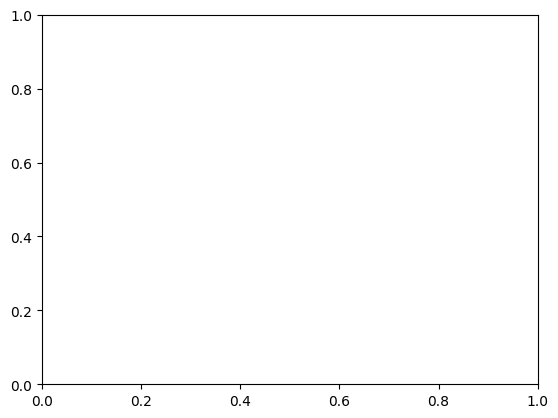

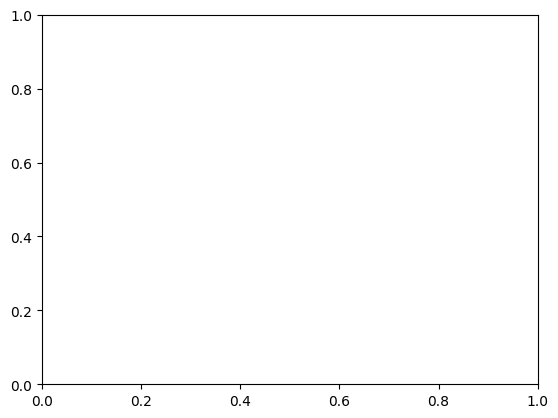

In [11]:

EVAL_NUM =    5 # number of evaluations for a single noise type

# STORE_DICT = "/home/ecabiati/storage/resnet9s_models/resnet9_aihwkit/"
STORE_DICT = "/home/ecabiati/storage/resnet9s_models/resnet9_own_noise/"
# STORE_DICT = "./"

# = * = * = * = * = RPU CONFIG PARs = * = * = * = * = * =
gmax = 40.0 # uS maximum conductance mapped value

forward = IOParameters(
inp_res = 254.0,
out_res = 254.0,
# bound_management= BoundManagementType.NONE,
# noise_management= NoiseManagementType.NONE,
w_noise_type= WeightNoiseType.NONE,
)

clip = WeightClipParameter(
    type=WeightClipType.NONE,
)

remap = WeightRemapParameter(
    type=WeightRemapType.NONE,
)



# quantizer = WeightQuantizerParameter(
#     quantizer_type=WeightQuantizerType.NONE,
# )

# = * = * = * = * = RPU CONFIG PARs = * = * = * = * = * =

levels = [3, 5, 9, 17, 33]

accuracies = np.zeros((len(levels),len(types), EVAL_NUM))

for l, lv in enumerate(levels):

    quantizer = WeightQuantizerParameter(
        quantizer_type=WeightQuantizerType.UNIFORM_SYMMETRIC,
        levels = lv,
        rel_to_actual_wmax= True,
        resolution = 1./(lv-0.1),
        method = "none",
    )

    # quantization = WeightQuantizerParameter(
    #     levels = lv,
    #     method = "percentile",
    #     eps = 0.1,
    #     use_forward=True,
    # )

    # PREFIX = "resnet9_quantized_{}__results/".format(lv)
    PREFIX = "resnet9_qhwa_{}_results/".format(lv)

    # # Create the model and prepare it for evaluation
    # RESULTS_DICT =  STORE_DICT + PREFIX + "evaluation_results"
    # os.makedirs(RESULTS_DICT, exist_ok=True)

    # if lv == 3:
    #     STORE_DICT = "./"
    # else:
    #     STORE_DICT = "/home/ecabiati/storage/resnet9s_models/resnet9_own_noise/"

    RESNET_MODEL_DICT = STORE_DICT +PREFIX+ "resnet9_quant_{}.th".format(lv)
    print("Model to load: ", RESNET_MODEL_DICT)
    state_dict = torch.load(RESNET_MODEL_DICT, map_location=DEVICE)
    if hasattr(state_dict, "model_state_dict"):
        loading_state = state_dict["model_state_dict"]
    else:
        loading_state = state_dict
    

    for noise in types:
        print(noise)
        
        noise_model = ExperimentalNoiseModel(file_path=ex_path, 
                                        type = noise,
                                        levels = lv,
                                        force_interpolation=True,
                                        compensation=False,
                                        g_converter = SinglePairConductanceConverter(g_max=gmax))
        
        

        rpu_config = InferenceRPUConfig(
            forward = forward,
            clip = clip,
            remap = remap,
            quantization =  quantizer,
            drift_compensation = None,
            noise_model = noise_model,
        )


        for rep in range(EVAL_NUM):

            _, validation_data = load_images()
            criterion = nn.CrossEntropyLoss()

            model = resnet9s().to(DEVICE)
            model = convert_to_analog(model, rpu_config)
            print(rpu_config)
            model.load_state_dict(loading_state ,strict=True, load_rpu_config=False)
            if rep == 0:
                pl.generate_moving_hist(model, title = "DISCRETIZED model", file_name = "./test/this_analog_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)
            analog_model = convert_to_analog(model, rpu_config)
            analog_model.cuda()
            if rep == 0:
                pl.generate_moving_hist(analog_model, title = "DISCRETIZED model", file_name = "./test/this_quantized_analog_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)
            analog_model.eval()

            # progam the model with the selected noise model
            analog_model.program_analog_weights()
            if rep == 0:
                pl.generate_moving_hist(analog_model, title = "DISCRETIZED model", file_name = "./test/this_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)
            

            # evaluate the model
            _, _, _, accuracies[l, types.index(noise), rep] = test_evaluation(validation_data, analog_model, nn.CrossEntropyLoss())

            del analog_model
            torch.cuda.empty_cache()

        print(f"Accuracy for noise {noise} , lv {lv}--> mean : {np.mean(accuracies[l,types.index(noise)])}, std: {np.std(accuracies[l,types.index(noise)])}")
torch.save(accuracies, STORE_DICT + "accuracies_own_noise.th")



    

85.84
[68.33  60.932 66.48  59.094 51.512 50.158 56.4   67.516]


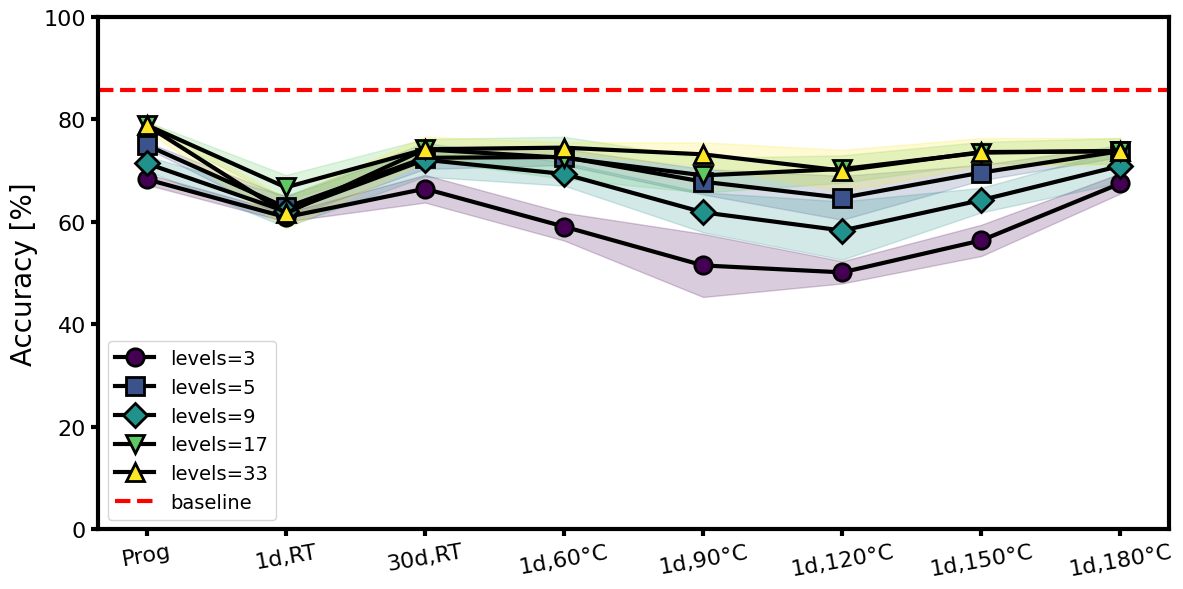

In [9]:
import matplotlib

STORE_DICT = "/home/ecabiati/storage/resnet9s_models/resnet9_own_noise/"
levels = [3, 5, 9, 17, 33]
accuracies = torch.load(STORE_DICT + "accuracies_own_noise.th")

DUMP_DIR = os.path.join('/home/ecabiati/storage/inference_results')
results0  =  torch.load(os.path.join(DUMP_DIR, "results_resnet9s_own.th"))
aihwkit_non_quantized_noise = results0["non_quantized"]
print(aihwkit_non_quantized_noise)


# Plot the accuracies: create a line for each level with a different color and marker.
# For each level, plot the mean accuracies for each noise type and the 68% confidence interval.
# The x-axis should be the noise type and the y-axis the accuracy.
# The plot should have a legend with the level number.

fig, ax = plt.subplots(1,1, figsize=(12,6))

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(levels)))
markers = ["o", "s", "D", "v", "^"]

for l, lv in enumerate(levels):
    
    mean_acc = np.mean(accuracies[l], axis=1)
    if lv == 3:
        print(mean_acc)
    std_acc = np.std(accuracies[l], axis=1)
    ax.plot(types, mean_acc, color="k", marker=markers[l], label=f"levels={lv}", markersize=12.5, markerfacecolor= colors[l], markeredgewidth=2, linewidth=3)
    ax.fill_between(types, mean_acc - std_acc, mean_acc + std_acc, color=colors[l], alpha=0.2)
# add the non-quanitzed model
ax.axhline(y=aihwkit_non_quantized_noise, color="r", linestyle="--", label="baseline", linewidth=3)

ax.set_ylabel("Accuracy [%]", fontsize=20)
# set the range of the y-axis between 0 and 100
ax.set_ylim(0, 100)

ax.legend( fontsize=14)
# ax.grid(True, which="major", linestyle="-", linewidth=1.5)
# ax.grid(True, which="minor", linestyle="--")

#make the ticks size bigger
ax.tick_params(axis = "both", which = "major", labelsize = 20)
ax.tick_params(width = 3, length = 5)
# make the box thicker
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

#make the frame thicker
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)





plt.xticks(rotation=10)
#increase the font size for the labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
